In [1]:
1+1

2

In [1]:
from typing_extensions import TypedDict

from langgraph.graph import StateGraph, START, END

## Reducers
from typing import Annotated
from langgraph.graph.message import add_messages

In [2]:
class State(TypedDict):
    messages: Annotated[list, add_messages]

In [3]:
import os
from dotenv import load_dotenv

load_dotenv()

os.environ["OPENAI_API_KEY"] = os.getenv("OPENAI_API_KEY")
os.environ["GROQ_API_KEY"] = os.getenv("GROQ_API_KEY")

In [4]:
from langchain_groq import ChatGroq
llm_groq = ChatGroq(model="meta-llama/llama-4-scout-17b-16e-instruct")
llm_groq

ChatGroq(output_version=None, profile={'max_input_tokens': 131072, 'max_output_tokens': 8192, 'image_inputs': True, 'audio_inputs': False, 'video_inputs': False, 'image_outputs': False, 'audio_outputs': False, 'video_outputs': False, 'reasoning_output': False, 'tool_calling': True}, client=<groq.resources.chat.completions.Completions object at 0x0000028C15D80C20>, async_client=<groq.resources.chat.completions.AsyncCompletions object at 0x0000028C15D816A0>, model_name='meta-llama/llama-4-scout-17b-16e-instruct', model_kwargs={}, groq_api_key=SecretStr('**********'), groq_api_base=None, groq_proxy=None)

### We Will Start With Creating Nodes

In [5]:
from langgraph.checkpoint.memory import MemorySaver

memory = MemorySaver()

def superbot(state: State):
    return {"messages": [llm_groq.invoke(state['messages'])]}

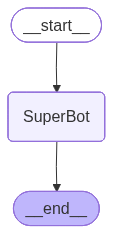

In [6]:
graph = StateGraph(State)

## node
graph.add_node("SuperBot", superbot)

## Edges
graph.add_edge(START, "SuperBot")
graph.add_edge("SuperBot", END)

graph_builder = graph.compile(checkpointer=memory)

## Display
from IPython.display import Image, display

display(Image(graph_builder.get_graph().draw_mermaid_png()))

In [8]:
## Invocation

config = {"configurable": {"thread_id": "1"}}

graph_builder.invoke(
    {"messages": "Hi, My name is Krish And I like cricket"},
    config=config
)

{'messages': [HumanMessage(content='Hi, My name is Krish And I like cricket', additional_kwargs={}, response_metadata={}, id='ca3a09c9-0f4e-4bd4-81fa-6098d75bcec5'),
  AIMessage(content="Hello Krish! It's nice to meet you! Cricket is a fantastic sport, isn't it? Which team do you support? Are you a fan of Virat Kohli, Rohit Sharma, or maybe someone else? Do you play cricket yourself or just enjoy watching it? Let's chat!", additional_kwargs={}, response_metadata={'token_usage': {'completion_tokens': 58, 'prompt_tokens': 20, 'total_tokens': 78, 'completion_time': 0.132441584, 'completion_tokens_details': None, 'prompt_time': 9.9749e-05, 'prompt_tokens_details': None, 'queue_time': 0.046108961, 'total_time': 0.132541333}, 'model_name': 'meta-llama/llama-4-scout-17b-16e-instruct', 'system_fingerprint': 'fp_37da608fc1', 'service_tier': 'on_demand', 'finish_reason': 'stop', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--019ea252-f1a9-7df0-beef-24e82c05c87d-0', tool_calls=[], inval

**Streaming**

**Methods:** `.stream()` and `astream()`

* These methods are sync and async methods for streaming back results.

**Additional parameters in streaming modes for graph state**

* **values** : This streams the full state of the graph after each node is called.
* **updates** : This streams updates to the state of the graph after each node is called.
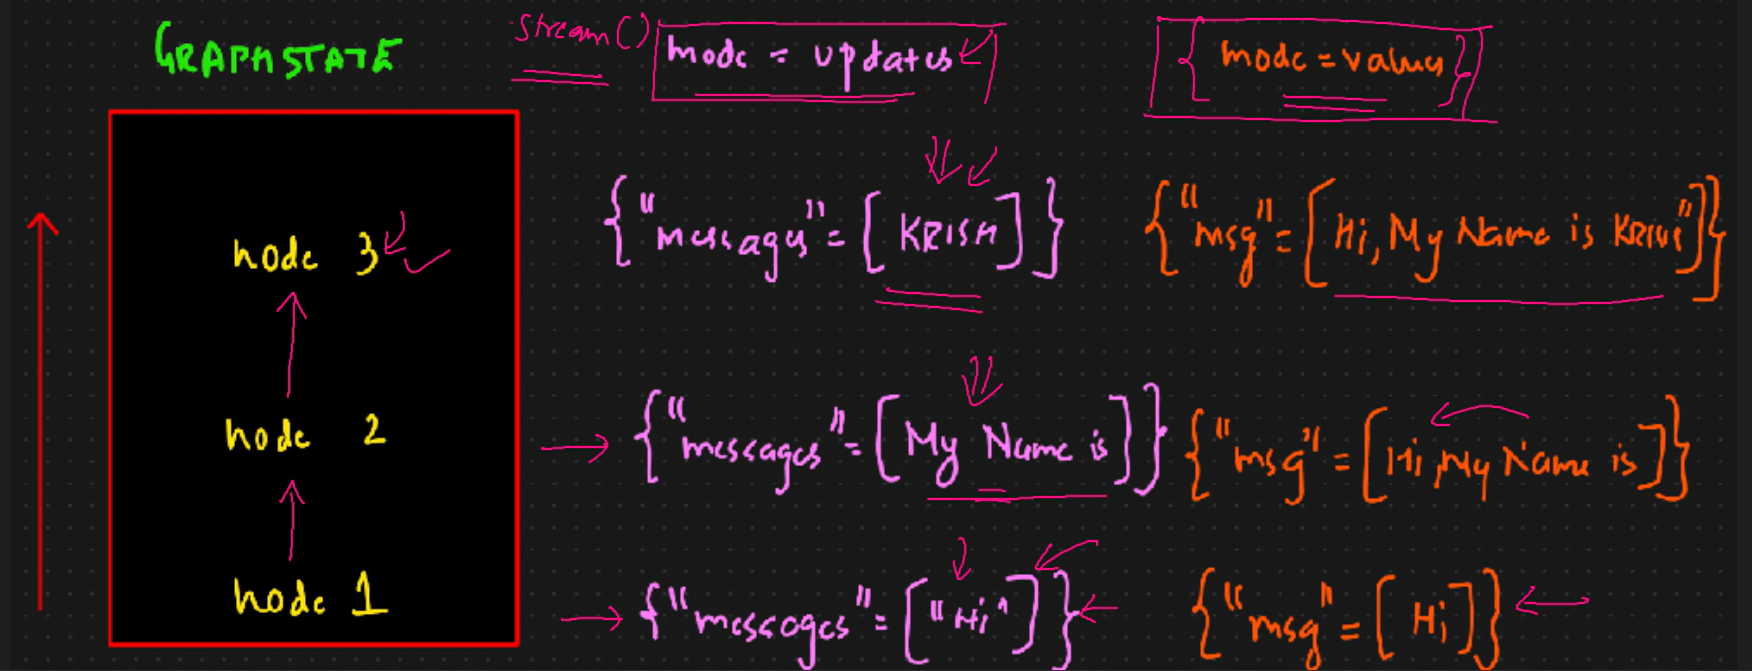

### Streaming the messages with stream method

In [9]:
## create a thread
# Create a thread
config = {"configurable": {"thread_id": "2"}}

for chunk in graph_builder.stream({"messages": "Hi, My name is Krish And I like cricket"},config,stream_mode="updates"):
    print(chunk)

{'SuperBot': {'messages': [AIMessage(content="Hello Krish! Nice to meet you! Cricket is an amazing sport, isn't it? Which team or player is your favorite? Are you a fan of the game from a particular country or league, like the IPL or international matches? Let's chat about cricket!", additional_kwargs={}, response_metadata={'token_usage': {'completion_tokens': 52, 'prompt_tokens': 20, 'total_tokens': 72, 'completion_time': 0.118174499, 'completion_tokens_details': None, 'prompt_time': 0.000430727, 'prompt_tokens_details': None, 'queue_time': 0.052526463, 'total_time': 0.118605226}, 'model_name': 'meta-llama/llama-4-scout-17b-16e-instruct', 'system_fingerprint': 'fp_37da608fc1', 'service_tier': 'on_demand', 'finish_reason': 'stop', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--019ea254-1b5e-7033-983e-0ba3cc5d263d-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 20, 'output_tokens': 52, 'total_tokens': 72})]}}


In [10]:
# Create a thread
config = {"configurable": {"thread_id": "2"}}

for chunk in graph_builder.stream({"messages": "Hi, My name is Krish And I like cricket"},config,stream_mode="values"):
    print(chunk)

{'messages': [HumanMessage(content='Hi, My name is Krish And I like cricket', additional_kwargs={}, response_metadata={}, id='70c5e20c-6777-46da-a182-68ecb3f1820c'), AIMessage(content="Hello Krish! Nice to meet you! Cricket is an amazing sport, isn't it? Which team or player is your favorite? Are you a fan of the game from a particular country or league, like the IPL or international matches? Let's chat about cricket!", additional_kwargs={}, response_metadata={'token_usage': {'completion_tokens': 52, 'prompt_tokens': 20, 'total_tokens': 72, 'completion_time': 0.118174499, 'completion_tokens_details': None, 'prompt_time': 0.000430727, 'prompt_tokens_details': None, 'queue_time': 0.052526463, 'total_time': 0.118605226}, 'model_name': 'meta-llama/llama-4-scout-17b-16e-instruct', 'system_fingerprint': 'fp_37da608fc1', 'service_tier': 'on_demand', 'finish_reason': 'stop', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--019ea254-1b5e-7033-983e-0ba3cc5d263d-0', tool_calls=[], invalid

In [11]:
for chunk in graph_builder.stream({"messages": "I also like football"},config,stream_mode="values"):
    print(chunk)

{'messages': [HumanMessage(content='Hi, My name is Krish And I like cricket', additional_kwargs={}, response_metadata={}, id='70c5e20c-6777-46da-a182-68ecb3f1820c'), AIMessage(content="Hello Krish! Nice to meet you! Cricket is an amazing sport, isn't it? Which team or player is your favorite? Are you a fan of the game from a particular country or league, like the IPL or international matches? Let's chat about cricket!", additional_kwargs={}, response_metadata={'token_usage': {'completion_tokens': 52, 'prompt_tokens': 20, 'total_tokens': 72, 'completion_time': 0.118174499, 'completion_tokens_details': None, 'prompt_time': 0.000430727, 'prompt_tokens_details': None, 'queue_time': 0.052526463, 'total_time': 0.118605226}, 'model_name': 'meta-llama/llama-4-scout-17b-16e-instruct', 'system_fingerprint': 'fp_37da608fc1', 'service_tier': 'on_demand', 'finish_reason': 'stop', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--019ea254-1b5e-7033-983e-0ba3cc5d263d-0', tool_calls=[], invalid

In [12]:
for chunk in graph_builder.stream({"messages": "I love sports"},config,stream_mode="values"):
    print(chunk)

{'messages': [HumanMessage(content='Hi, My name is Krish And I like cricket', additional_kwargs={}, response_metadata={}, id='70c5e20c-6777-46da-a182-68ecb3f1820c'), AIMessage(content="Hello Krish! Nice to meet you! Cricket is an amazing sport, isn't it? Which team or player is your favorite? Are you a fan of the game from a particular country or league, like the IPL or international matches? Let's chat about cricket!", additional_kwargs={}, response_metadata={'token_usage': {'completion_tokens': 52, 'prompt_tokens': 20, 'total_tokens': 72, 'completion_time': 0.118174499, 'completion_tokens_details': None, 'prompt_time': 0.000430727, 'prompt_tokens_details': None, 'queue_time': 0.052526463, 'total_time': 0.118605226}, 'model_name': 'meta-llama/llama-4-scout-17b-16e-instruct', 'system_fingerprint': 'fp_37da608fc1', 'service_tier': 'on_demand', 'finish_reason': 'stop', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--019ea254-1b5e-7033-983e-0ba3cc5d263d-0', tool_calls=[], invalid

**Streaming The Responses With `astream` Method**

**Streaming tokens** — We often want to stream more than graph state.

In particular, with chat model calls it is common to stream the **tokens** as they are generated.

We can do this using the `.astream_events` method, which streams back events as they happen inside nodes!

Each event is a dict with a few keys:

* **event**: This is the type of event that is being emitted.
* **name**: This is the name of event.
* **data**: This is the data associated with the event.
* **metadata**: Contains `langgraph_node`, the node emitting the event.


In [13]:
config = {"configurable":{"thread_id":"3"}}

async for event in graph_builder.astream_events({"messages":"Hi My name is Krish and I like cricket"},config,version="v2"):
    print(event)

{'event': 'on_chain_start', 'data': {'input': {'messages': 'Hi My name is Krish and I like cricket'}}, 'name': 'LangGraph', 'tags': [], 'run_id': '019ea25f-cfb7-7fa0-baeb-d3b67c29d8e3', 'metadata': {'thread_id': '3', 'ls_integration': 'langgraph'}, 'parent_ids': []}
{'event': 'on_chain_start', 'data': {'input': {'messages': [HumanMessage(content='Hi, My name is Krish And I like cricket', additional_kwargs={}, response_metadata={}, id='d7d478ee-5272-4bff-96c8-3a69465136dd'), AIMessage(content="Hello Krish! Nice to meet you! Cricket is an amazing sport, isn't it? Which team do you support? Are you a fan of Virat Kohli, Rohit Sharma, or someone else? Do you play cricket yourself or just enjoy watching it? Let's chat!", additional_kwargs={}, response_metadata={'token_usage': {'completion_tokens': 56, 'prompt_tokens': 20, 'total_tokens': 76, 'completion_time': 0.127286015, 'completion_tokens_details': None, 'prompt_time': 0.000119739, 'prompt_tokens_details': None, 'queue_time': 0.04541151,